# Step 1: Data Exploration & Cleaning

For the Tardis project , we will need some libraries

In [ ]:
import pandas as pd  # panda for open a csv and extract the data for file and data manipulation
import matplotlib.pyplot as pl  # matplotlib to create visualisation via graphs

This are some macros to change the way the code is 

In [ ]:
# this is the filename use for the analisys
DATASET = "datasets/dataset.csv"

# this the list of the columns name that have to be transform to numeric
COLUMNS_TO_NUMERIC = [
    "Average journey time",
    "Number of scheduled trains",
    "Number of cancelled trains",
    "Number of trains delayed at departure",
    "Average delay of late trains at departure",
    "Average delay of all trains at departure",
    "Number of trains delayed at arrival",
    "Average delay of late trains at arrival",
    "Average delay of all trains at arrival",
    "Number of trains delayed > 15min",
    "Average delay of trains > 15min (if competing with flights)",
    "Number of trains delayed > 30min",
    "Number of trains delayed > 60min",
    "Pct delay due to external causes",
    "Pct delay due to infrastructure",
    "Pct delay due to traffic management",
    "Pct delay due to rolling stock",
    "Pct delay due to station management and equipment reuse",
    "Pct delay due to passenger handling (crowding, disabled persons, connections)",
]

# this is the column name for departure station
DEPARTURE = "Departure station"

# this is the column name for arrival station
ARRIVAL = "Arrival station"

# create a type reference dataframe
type dataframe = pd.DataFrame

# this is the column name for date
DATE = "Date"

# list of columns name for delay with % due to cause
delay_pct_columns = [
    "Pct delay due to external causes",
    "Pct delay due to infrastructure",
    "Pct delay due to traffic management",
    "Pct delay due to rolling stock",
]

# list of columns name for delay with % due to cause
delay_natural_columns = [
    "Pct delay due to external causes",
    "Pct delay due to rolling stock",
]

# list of columns name for delay for departure and arrival
delay_departure_arrival_columns = [
    "Number of trains delayed at departure",
    "Average delay of all trains at departure",
    "Number of trains delayed at arrival",
    "Average delay of all trains at arrival",
]

# filename of the output file for the cleaned csv
CSV_CLEANED_OUTPUT = "cleaned_dataset.csv"

# columns with comments inside
COMMENTS = [
    "Cancellation comments",
    "Departure delay comments",
    "Arrival delay comments",
]

## Open the dataset and clean it

Open the file and save the dataframe

In [ ]:
raw_df = pd.read_csv(DATASET, on_bad_lines="skip", sep=";")
# on_bad_lines skip : if invalid lines are discovered during the parsing, they'll be skip
# sep ";" : it's a file with data separate by ";" so we precise into the function that each value is separate by a ";"

And this is a tab representation of the file

In [ ]:
raw_df

Let's drop comments columns

In [ ]:
raw_df.drop(columns=COMMENTS, inplace=True)  # remove columns with comments inside

## Let's check our dataframe

In [ ]:
raw_df.describe()

In [ ]:
shape = raw_df.shape
print(f"The dataframe contain {shape[0]} rows and {shape[1]} columns")

#### Let's check the columns name and their type

In [ ]:
raw_df.columns  # a method that display columns of the dataframe and their data type

All the columns are string / characters we need to change the type of some columns.

#### Let's check the first rows of the dataframe

In [ ]:
raw_df.head()  # a method that display the first rows of the dataframe

#### Let's check the first rows of the dataframe

In [ ]:
raw_df.tail()  # a method that display the last rows of the dataframe

There are some missing values in the rows.

#### Let's check the dataframe info

In [ ]:
raw_df.info()  # this is a usefull method

That display :
- the class used
- the number of rows with the minimum index and the max
- the number of columns
- each column with the type , an column index

## Let's clean our dataframe

We choose to remove the whole row if there are duplicates only and keep the line with empty cell.

Now we remove duplicate rows

In [ ]:
df = raw_df.drop_duplicates(
    ignore_index=True
)  # df is the result of the action of removing rows
# ignore_index=True is a parameter that permit to give new index to the df's rows, without it the new rows will keep their old index

The duplicates rows are now removed. For the empty cell we choose to fill them depending of the other values. But first we need to transform some columns into numeric values.

In [ ]:
for col in (
    COLUMNS_TO_NUMERIC
):  # COLUMNS_TO_NUMERIC is a list of the columns we have to change
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(",", "."), errors="coerce"
    )  # we transform "str" value to numeric
# and we replace the dot by coma for decimal values

We can change the format for the date

In [ ]:
df["Date"] = pd.to_datetime(df["Date"], format="%Y-%m", errors="coerce").dt.to_period(
    "M"
)
df.dropna(subset=["Date"], inplace=True)  # drop row if missing value in date
df

The function above transform the "str" value to a time value as we figured out that the format used in the file was year-month
so we are keeping the year and the month only and if the value can't be tranform "Nat" will be display instead

We need to standardise the station name: no caps, no space at the beginning and weed need a value.

This is the standardise station function, we simply call the function with the dataframe and the column to standardise and Voilà!

In [ ]:
def standardise_station(df: dataframe, column_name: str) -> None:
    """
    Standardise the column value in the dataframe

    Parameters
    ----------
    df : dataframe
        a dataframe.
    column_name : str
        the column name.

    Returns
    -------
    None
    """
    df[column_name] = df[column_name].str.strip()  # remove space at start and end
    df[column_name] = df[column_name].str.lower()  # lower characters
    df[column_name] = df[column_name].replace(
        {r"\bst\b": "saint"}, regex=True
    )  # change "st" to "saint"
    df[column_name] = df[
        column_name
    ].str.title()  # put a maj character at the start of each words

Strip function will remove spaces at the start and at the end of the string
Lower function will change all characters to their lower version
We are using strip and not lstrip (remove the space at the start) nor rstrip (remove the space at the start)
Replace function will take any "st" and transform it to "saint" , \b will delimit the partern "st", a 2 letter word and not a part of a word
to use the \b we need to use a raw string ( r"....." ) and we need to says regex is true otherwise that will don't work the way we want 

In [ ]:
standardise_station(df, DEPARTURE)  # standardise the departure station
standardise_station(df, ARRIVAL)  # standardise the arrival station
df = df[
    df[DEPARTURE] != df[ARRIVAL]
]  # col1 : "banana" and col2: "banana" -> remove line, remove only row when arrival is equal to departure station
df
# print(df[DEPARTURE])

In [ ]:
def to_period(df: dataframe, column_name=DATE, month=False, year=False):
    """
    Create a copy of the dataframe and change the column values for a period in Month only or Year only

    Parameters
    ----------
    df : dataframe
        a dataframe.
    column_name : str
        the column name, by default is DATE (the macro).
    month: bool
        a boolean to says if you want period in months
    year: bool
        a boolean to says if you want period in years

    Returns
    -------
    dataframe or None (depend of the given argument)
    """
    if month == year:  # if true true | false false
        return None  # ro result
    res = df.copy()  # create a copy so we don't modify the base dataframe
    res = res.dropna(subset=[DATE])  # drop empty values
    if month == True:  # true false
        res[column_name] = res[column_name].dt.month  # we keep the months only
    if year == True:  # false true
        res[column_name] = res[column_name].dt.year  # we keep the years only
    return res  # return the modified copy of the dataframe

## Fill the gap

Now we transform our values in a type we want, we can use the values to fill empty cell. We need to fill the empty numercial values. We have the choice between three function: ffill , bfill and interpolate.

### What function to use?

"ffill" function will take the forward value and copy paste it to the empty cells.
By the same principle "bfill" function will take the backward value and copy paste it to the empty cells.
Fortunatly there is the "interpolate" function that will do calculation and give us a value depending of the other values of the dataframe. 
This is not perfect, but it's far better that simply copy pasting a neighbour value.

In [ ]:
df[COLUMNS_TO_NUMERIC] = df[COLUMNS_TO_NUMERIC].interpolate()
df

Get all station name

In [ ]:
df_departure_station = df.dropna(subset=["Departure station"])
stations = df_departure_station["Departure station"].unique()
for station in stations:
    print(station)

Now we cleaned and fill the dataframe, it's time to create useful dataframes

### But first let's save our cleaned dataframe

In [ ]:
df.to_csv(
    CSV_CLEANED_OUTPUT, sep=";"
)  # save the dataframe by creating a csv file with ";" as separator

### A dataframe based on delay time and period

In [ ]:
def create_df_period_and(df: dataframe, columns_names: list, month=False, year=False):
    """
    Create a copy of the dataframe and change the column values for a period in Month only or Year only, and keep the only the columns inside the columns_names

    Parameters
    ----------
    df : dataframe
        a dataframe.
    columns_names : list of str
        columns names are a list of columns name to keep.
    month: bool
        a boolean to says if you want period in months
    year: bool
        a boolean to says if you want period in years

    Returns
    -------
    dataframe or None (depend of the given argument)
    """
    res = to_period(
        df, year=year, month=month
    )  # create a copy of the dataframe and replace the DATE (macro) column with year / month only
    if res is None:  # check if the copy don't work
        return None  # return empty dataframe
    selected_cols = (
        [DATE] + [c for c in columns_names if c in res.columns and c != DATE]
    )  # create a list of columns with the columns names in the list given in parameter only with the column is part of the dataframe columns
    return res[selected_cols]  # return the columns we want only

### We choose to create :

#### A dataframe based on departure and arrival delay

By year:

In [ ]:
df_departure_arrival_delay_year = create_df_period_and(
    df, delay_departure_arrival_columns, month=False, year=True
)
df_departure_arrival_delay_year

By month:

In [ ]:
df_departure_arrival_delay_month = create_df_period_and(
    df, delay_departure_arrival_columns, month=True, year=False
)
df_departure_arrival_delay_month

#### A dataframe based on natural cause delay

By year:

In [ ]:
df_natural_delay_year = create_df_period_and(
    df, delay_natural_columns, month=False, year=True
)
df_natural_delay_year

By month:

In [ ]:
df_natural_delay_month = create_df_period_and(
    df, delay_natural_columns, month=True, year=False
)
df_natural_delay_month

#### A dataframe based on percentage of multiples cause delay

By year:

In [ ]:
df_pct_delay_year = create_df_period_and(df, delay_pct_columns, month=False, year=True)
df_pct_delay_year

By month:

In [ ]:
df_pct_delay_month = create_df_period_and(df, delay_pct_columns, month=True, year=False)
df_pct_delay_month

# Step 2: Data Visualization & Analysis

In this step, we are going to create some interestings graphs based on the cleaned version of the given dataset, previously cleaned in the first step.

First, let's check the average delay at arrival.

Some macros used in the step 2

In [ ]:
# color of the plot
PLOT_COLOR = "tab:blue"

# color of the line
LINE_COLOR = "tab:red"

# line style
LINE_STYLE = "--"

# x label information
X_LABEL = "Date"

# target year
YEAR = 2022

# service column
SERVICE = "Service"

# international column
INTERNATIONAL = "International"

# national column
NATIONAL = "National"

# international plot color
INTERNATIONAL_PLOT_COLOR = "tab:orange"

# national plot color
NATIONAL_PLOT_COLOR = "tab:blue"

In [ ]:
# columns of the average delay at arrival
DELAY_COL = "Average delay of all trains at arrival"

# title of the graph
TITLE = "Retard moyen a l'arrivee par année"

# y label information
Y_LABEL = "Retard moyen (minutes)"

# line label
LINE_LABEL = f"Moyenne globale: {mean_delay:.2f} min"

monthly_delay = ( 
    df[[DATE, DELAY_COL]]
    .dropna()
    .sort_values(DATE)
    .groupby(DATE, as_index=False)[DELAY_COL]
    .mean()
 )

fig, ax = pl.subplots(figsize=(10, 5))
ax.plot(
    monthly_delay[DATE].dt.to_timestamp(),
    monthly_delay[DELAY_COL],
    color=PLOT_COLOR,
    linewidth=2
 )

mean_delay = monthly_delay[DELAY_COL].mean()
ax.axhline(mean_delay, color=LINE_COLOR, linestyle=LINE_STYLE, linewidth=1.8,
           label=LINE_LABEL)

ax.set_title(TITLE)
ax.set_xlabel(X_LABEL)
ax.set_ylabel(Y_LABEL)
ax.legend()
ax.grid(alpha=0.25)
pl.tight_layout()
pl.show()

So we have an average of 6.08 minutes of delay on the dataset. We can observe some regulars peaks for the holidays every years and a fall during the Covid-19 perdiod.

Let's watch exactly each year , for example the year 2022:

In [ ]:
# columns of the average delay at arrival
DELAY_COL = "Average delay of all trains at arrival"

# title of the graph
TITLE = "Retard moyen a l'arrivee par mois"

# y label information
Y_LABEL = "Retard moyen (minutes)"

# line label
LINE_LABEL = f"Moyenne globale: {mean_delay:.2f} min"

monthly_delay = ( 
    df.loc[df[DATE].dt.year == YEAR, [DATE, DELAY_COL]]
    .dropna()
    .sort_values(DATE)
    .groupby(DATE, as_index=False)[DELAY_COL]
    .mean()
 )

fig, ax = pl.subplots(figsize=(10, 5))
ax.plot(
    monthly_delay[DATE].dt.to_timestamp(),
    monthly_delay[DELAY_COL],
    color=PLOT_COLOR,
    linewidth=2
 )

mean_delay = monthly_delay[DELAY_COL].mean()
ax.axhline(mean_delay, color=LINE_COLOR, linestyle=LINE_STYLE, linewidth=1.8,
           label=LINE_LABEL)

ax.set_title(TITLE)
ax.set_xlabel(X_LABEL)
ax.set_ylabel(Y_LABEL)
ax.legend()
ax.grid(alpha=0.25)
pl.tight_layout()
pl.show()

There is a peak of delay during the summer holidays, exactly the same we observe before.

Let's watch the canceled train during the year 2022:

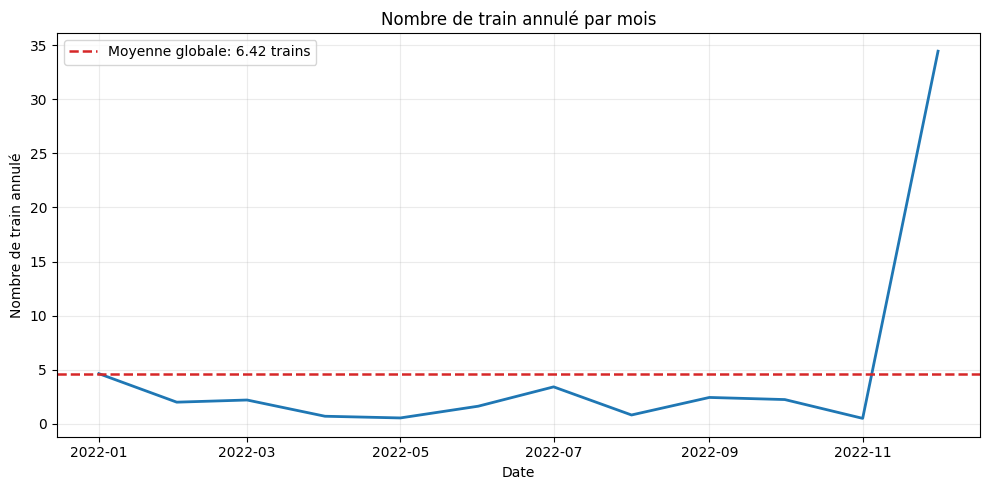

In [152]:
# columns of the average delay at arrival
DELAY_COL = "Number of cancelled trains"

# title of the graph
TITLE = "Nombre de train annulé par mois"

# y label information
Y_LABEL = "Nombre de train annulé"

# line label
LINE_LABEL = f"Moyenne globale: {mean_delay:.2f} trains"

monthly_delay = ( 
    df.loc[df[DATE].dt.year == YEAR, [DATE, DELAY_COL]]
    .dropna()
    .sort_values(DATE)
    .groupby(DATE, as_index=False)[DELAY_COL]
    .mean()
 )

fig, ax = pl.subplots(figsize=(10, 5))
ax.plot(
    monthly_delay[DATE].dt.to_timestamp(),
    monthly_delay[DELAY_COL],
    color=PLOT_COLOR,
    linewidth=2
 )

mean_delay = monthly_delay[DELAY_COL].mean()
ax.axhline(mean_delay, color=LINE_COLOR, linestyle=LINE_STYLE, linewidth=1.8,
           label=LINE_LABEL)


ax.set_title(TITLE)
ax.set_xlabel(X_LABEL)
ax.set_ylabel(Y_LABEL)
ax.legend()
ax.grid(alpha=0.25)
pl.tight_layout()
pl.show()

If we exclude the summer holidays, we can observe not that many canceled train execept for the winter holidays with new records.

The graph below is for the delay for each servicies

In [ ]:
# columns of the average delay at arrival
DELAY_COL = "Average delay of all trains at arrival"

# title of the graph
TITLE = "Retard moyen a l'arrivee par mois"

# y label information
Y_LABEL = "Retard moyen (minutes)"

# line label
LINE_LABEL = f"Moyenne globale: {mean_delay:.2f} min"

filtered = df.loc[
    df[DATE].dt.year == YEAR,
    [DATE, SERVICE, DELAY_COL]
].dropna()

monthly_delay = ( 
    df.loc[df[DATE].dt.year == YEAR, [DATE, DELAY_COL]]
    .dropna()
    .sort_values(DATE)
    .groupby(DATE, as_index=False)[DELAY_COL]
    .mean()
 )

monthly_delay_by_service = (
    filtered
    .groupby([DATE, SERVICE], as_index=False)[DELAY_COL]
    .mean()
    .pivot(index=DATE, columns=SERVICE, values=DELAY_COL)
)


fig, ax = pl.subplots(figsize=(10, 5))
ax.plot(
    monthly_delay[DATE].dt.to_timestamp(),
    monthly_delay[DELAY_COL],
    color=PLOT_COLOR,
    linewidth=2
 )

if NATIONAL in monthly_delay_by_service.columns:
    ax.plot(
        monthly_delay_by_service.index.to_timestamp(),
        monthly_delay_by_service[NATIONAL],
        label=NATIONAL,
        color=NATIONAL_PLOT_COLOR,
        linewidth=2
    )

if INTERNATIONAL in monthly_delay_by_service.columns:
    ax.plot(
        monthly_delay_by_service.index.to_timestamp(),
        monthly_delay_by_service[INTERNATIONAL],
        label=INTERNATIONAL,
        color=INTERNATIONAL_PLOT_COLOR,
        linewidth=2
    )

mean_delay = monthly_delay[DELAY_COL].mean()
ax.axhline(mean_delay, color=LINE_COLOR, linestyle=LINE_STYLE, linewidth=1.8,
           label=LINE_LABEL)

ax.set_title(TITLE)
ax.set_xlabel(X_LABEL)
ax.set_ylabel(Y_LABEL)
ax.legend()
ax.grid(alpha=0.25)
pl.tight_layout()
pl.show()

The internationals trains are far more higher

In [ ]:
# title of the graph
TITLE = "Nombre par service"

# y label information
Y_LABEL = "Nombre de train"

# bar color left
BAR_COLOR_LEFT = "tab:red"

# bar color right
BAR_COLOR_RIGHT = "tab:blue"

fig, ax = pl.subplots()


sete = df[SERVICE].value_counts()

fruits = [INTERNATIONAL, NATIONAL]
counts = [sete.International, sete.National]
bar_colors = [BAR_COLOR_LEFT, BAR_COLOR_RIGHT]

ax.bar(fruits, counts, color=bar_colors)

ax.set_ylabel(Y_LABEL)
ax.set_title(TITLE)

pl.show()

That is the explanation of the graph being higher when there are less trains, so less data used. That is the reason behind the difference between the national and international.